In [1]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, TensorDataset
import optuna
import torch.nn as nn
import sklearn

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Load data
def load_embeddings(file_path):
    print(f"Loading embeddings from {file_path}...")
    df = pd.read_pickle(file_path)
    df["MatchID"] = df["ID"].apply(lambda x: x.split("_")[0])  # Extract MatchID from ID
    print(f"Loaded {len(df)} PeriodIDs.")
    return df

train_file = "processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels.pkl"
test_file = "processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl"

train_df = load_embeddings(train_file)
test_df = load_embeddings(test_file)

Loading embeddings from processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels.pkl...
Loaded 2137 PeriodIDs.
Loading embeddings from processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl...
Loaded 516 PeriodIDs.


In [4]:
# Split games into training/validation and internal test sets
all_games = train_df["MatchID"].unique()
np.random.seed(42)
np.random.shuffle(all_games)

internal_test_games = all_games[:3]  # Reserve 3 games for internal testing
train_val_games = all_games[3:]     # Remaining games for training/validation

train_val_df = train_df[train_df["MatchID"].isin(train_val_games)]
internal_test_df = train_df[train_df["MatchID"].isin(internal_test_games)]

In [5]:
train_val_df.head()

,ID,EventType,aggregated_embedding,MatchID
310,11_0,0,"[0.0034501683, -0.005461421, 0.0027932562, 0.0...",11
311,11_1,0,"[0.0025155172, -0.004367303, 0.0023437869, 0.0...",11
312,11_10,1,"[-0.00253083, 0.0049650557, -0.0016776714, -0....",11
313,11_100,0,"[0.003040051, -0.0062411577, 0.0031189043, 0.0...",11
314,11_101,0,"[0.0030895006, -0.007690724, 0.0036146063, 0.0...",11


In [6]:
# Create cross-validation splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_data = []

for train_idx, val_idx in kf.split(train_val_games):
    train_split = train_val_games[train_idx]
    val_split = train_val_games[val_idx]

    train_df_cv = train_df[train_df["MatchID"].isin(train_split)]
    val_df_cv = train_df[train_df["MatchID"].isin(val_split)]

    cv_data.append((train_df_cv, val_df_cv))


In [7]:
class LSTMAttentionModel(nn.Module):
    def __init__(self, input_dim=256, reduced_dim=256, hidden_dim=128, dropout=0.35, num_classes=2):
        super().__init__()
        self.embedding_reduction = nn.Linear(input_dim, reduced_dim)
        self.batch_norm1 = nn.BatchNorm1d(reduced_dim)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(reduced_dim, hidden_dim, num_layers=1, bidirectional=False, batch_first=True)
        self.batch_norm2 = nn.BatchNorm1d(hidden_dim)
        self.residual = nn.Linear(reduced_dim, hidden_dim)  # Residual connection
        self.attention = nn.Linear(hidden_dim, 1)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        reduced = self.embedding_reduction(x)
        reduced = self.batch_norm1(reduced.permute(0, 2, 1)).permute(0, 2, 1)
        reduced = self.dropout(torch.relu(reduced))

        lstm_out, _ = self.lstm(reduced)
        lstm_out = self.batch_norm2(lstm_out.permute(0, 2, 1)).permute(0, 2, 1)

        # Add residual connection
        combined_out = lstm_out + self.residual(reduced)

        attention_weights = torch.softmax(self.attention(combined_out), dim=1)
        context_vector = torch.sum(attention_weights * combined_out, dim=1)

        return self.fc(context_vector)

In [8]:
# Create game-based data loaders
def create_game_based_data_loaders(df, batch_size, sequence_length, shuffle=True):
    game_loaders = {}
    grouped = df.groupby("MatchID")

    for match_id, group in grouped:
        all_embeddings = np.vstack(group["aggregated_embedding"].values).astype(np.float32)
        all_labels = group["EventType"].values.astype(int)

        sequences, labels = [], []
        for i in range(len(all_embeddings)):
            if i < sequence_length - 1:
                num_pads = sequence_length - 1 - i
                seq_emb = np.vstack((np.zeros((num_pads, all_embeddings.shape[1])), all_embeddings[:i + 1]))
                label = all_labels[i]
            else:
                seq_emb = all_embeddings[i - sequence_length + 1 : i + 1]
                label = all_labels[i]

            sequences.append(seq_emb)
            labels.append(label)

        dataset = TensorDataset(
            torch.tensor(sequences, dtype=torch.float32),
            torch.tensor(labels, dtype=torch.long),
        )
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
        game_loaders[match_id] = loader

    return game_loaders

In [9]:
def evaluate_model(model, loaders, device):
    model.eval()
    all_preds, all_labels = [], []
    confusion_matrix = np.zeros((2, 2), dtype=int)

    with torch.no_grad():
        for _, loader in loaders.items():
            for embeddings, labels in loader:
                embeddings, labels = embeddings.to(device), labels.to(device)
                outputs = model(embeddings)
                _, preds = torch.max(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                confusion_matrix += sklearn.metrics.confusion_matrix(labels.cpu().numpy(), preds.cpu().numpy(), labels=[0, 1])

    accuracy = sklearn.metrics.accuracy_score(all_labels, all_preds)
    return accuracy, confusion_matrix

In [10]:
import torch
from torch import nn
import copy

def train_model(
    model,
    train_df,
    val_df,
    sequence_length,
    batch_size,
    epochs,
    base_lr,
    max_lr,
    device,
    patience=(5, 0.01),
    clip_norm=1.0,
    weight_decay=1e-4
):
    """
    Train the model with or without a validation set.

    Args:
        model (nn.Module): The model to train.
        train_df (pd.DataFrame): Training DataFrame.
        val_df (pd.DataFrame or None): Validation DataFrame. If None, training is without validation.
        sequence_length (int): Length of input sequences.
        batch_size (int): Batch size for training.
        epochs (int): Maximum number of training epochs.
        base_lr (float): Base learning rate for the optimizer.
        max_lr (float): Maximum learning rate for the scheduler.
        device (torch.device): Device to run the training on (CPU or CUDA).
        patience (tuple, optional): (patience_epochs, delta) for early stopping.
                                     Defaults to (5, 0.01).
        clip_norm (float, optional): Maximum norm for gradient clipping. Defaults to 1.0.
        weight_decay (float, optional): L2 regularization weight. Defaults to 1e-4.

    Returns:
        nn.Module: Trained model with the best validation accuracy (if validation is provided).
                   Otherwise, the model trained on the entire training set.
    """
    # Create DataLoaders for training (and validation if provided)
    train_loaders = create_game_based_data_loaders(train_df, batch_size, sequence_length, shuffle=True)
    
    if val_df is not None:
        val_loaders = create_game_based_data_loaders(val_df, batch_size, sequence_length, shuffle=False)
        
        # Initialize optimizer and scheduler
        optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',
            factor=0.5,
            patience=3,
            verbose=True
        )
        
        # Loss function
        criterion = nn.CrossEntropyLoss()
        
        # Early Stopping parameters
        patience_epochs, delta = patience
        best_val_acc = 0.0
        best_model_state = None
        early_stop_counter = 0
        
        for epoch in range(epochs):
            model.train()
            total_loss = 0.0
            train_correct = 0
            train_total = 0
            
            # Training loop
            for _, loader in train_loaders.items():
                for embeddings, labels in loader:
                    embeddings = embeddings.to(device)
                    labels = labels.to(device)
                    
                    optimizer.zero_grad()
                    outputs = model(embeddings)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    
                    # Gradient clipping
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
                    
                    optimizer.step()
                    
                    total_loss += loss.item()
                    _, preds = torch.max(outputs, dim=1)
                    train_correct += (preds == labels).sum().item()
                    train_total += labels.size(0)
            
            train_acc = train_correct / train_total
            avg_loss = total_loss / train_total
            
            # Evaluation on validation set
            val_acc, val_confusion = evaluate_model(model, val_loaders, device)
            
            # Scheduler step based on validation accuracy
            scheduler.step(val_acc)
            
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
            print("Confusion Matrix:\n", val_confusion)
            
            # Early Stopping check
            if val_acc > best_val_acc + delta:
                best_val_acc = val_acc
                best_model_state = copy.deepcopy(model.state_dict())
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience_epochs:
                    print("Early stopping triggered.")
                    break
        
        # Load the best model state if validation was used
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
    
    else:
        # Training without validation
        # Initialize optimizer and scheduler
        optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=10,
            gamma=0.1
        )
        
        # Loss function
        criterion = nn.CrossEntropyLoss()
        
        for epoch in range(epochs):
            model.train()
            total_loss = 0.0
            train_correct = 0
            train_total = 0
            
            # Training loop
            for _, loader in train_loaders.items():
                for embeddings, labels in loader:
                    embeddings = embeddings.to(device)
                    labels = labels.to(device)
                    
                    optimizer.zero_grad()
                    outputs = model(embeddings)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    
                    # Gradient clipping
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
                    
                    optimizer.step()
                    
                    total_loss += loss.item()
                    _, preds = torch.max(outputs, dim=1)
                    train_correct += (preds == labels).sum().item()
                    train_total += labels.size(0)
            
            train_acc = train_correct / train_total
            avg_loss = total_loss / train_total
            
            # Scheduler step
            scheduler.step()
            
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}, Train Acc: {train_acc:.4f}")
    
    return model


In [11]:
def fine_tune_model(cv_data, device, n_trials=50):
    """
    Fine-tune hyperparameters using Optuna.

    Args:
        cv_data (list): Cross-validation data (train/validation splits).
        device (torch.device): Device to run the training on.
        n_trials (int): Number of trials for Optuna hyperparameter optimization.

    Returns:
        dict: Best hyperparameters found by Optuna.
    """
    def objective(trial):
        sequence_length = trial.suggest_int("sequence_length", 3, 10)
        reduced_dim = trial.suggest_int("reduced_dim", 128, 512)
        hidden_dim = trial.suggest_int("hidden_dim", 64, 512)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
        max_lr = trial.suggest_float("max_lr", lr * 2, lr * 10, log=True)
        batch_size = trial.suggest_int("batch_size", 16, 128)
        patience = trial.suggest_categorical("patience", [(5, 0.01), (10, 0.05)])
        clip_norm = trial.suggest_float("clip_norm", 0.5, 5.0)

        model = LSTMAttentionModel(
            input_dim=256,
            reduced_dim=reduced_dim,
            hidden_dim=hidden_dim,
            dropout=dropout,
            num_classes=2
        ).to(device)

        val_accuracies = []
        for train_df_cv, val_df_cv in cv_data:
            model_fold = LSTMAttentionModel(
                input_dim=256,
                reduced_dim=reduced_dim,
                hidden_dim=hidden_dim,
                dropout=dropout,
                num_classes=2
            ).to(device)

            trained_model = train_model(
                model=model_fold,
                train_df=train_df_cv,
                val_df=val_df_cv,
                sequence_length=sequence_length,
                batch_size=batch_size,
                epochs=20,
                base_lr=lr,
                max_lr=max_lr,
                device=device,
                patience=patience,
                clip_norm=clip_norm
            )

            val_loaders = create_game_based_data_loaders(val_df_cv, batch_size, sequence_length, shuffle=False)
            val_accuracy, _ = evaluate_model(trained_model, val_loaders, device)
            val_accuracies.append(val_accuracy)

        return np.mean(val_accuracies)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    print(f"Best Hyperparameters: {best_params}")
    return best_params


In [12]:
def create_game_based_sequences_with_ids(df, sequence_length):
    """
    Create sequences and corresponding last IDs from the DataFrame.

    Args:
        df (pd.DataFrame): DataFrame with 'MatchID', 'aggregated_embedding', and 'ID'.
        sequence_length (int): Length of each sequence.

    Returns:
        tuple: (sequences, dummy_labels, ids)
            - sequences: List of numpy arrays representing sequences.
            - dummy_labels: List of dummy labels (e.g., all zeros).
            - ids: List of last IDs in each sequence.
    """
    sequences = []
    dummy_labels = []
    ids = []
    grouped = df.groupby("MatchID")

    for match_id, group in grouped:
        try:
            all_embeddings = np.vstack(group["aggregated_embedding"].values).astype(np.float32)
            all_ids = group["ID"].values
        except ValueError as e:
            print(f"Error processing MatchID '{match_id}': {e}. Skipping this game.")
            continue

        for i in range(len(all_embeddings)):
            if i < sequence_length - 1:
                num_pads = sequence_length - 1 - i
                seq_emb = np.vstack((np.zeros((num_pads, all_embeddings.shape[1])), all_embeddings[:i + 1]))
                last_id = all_ids[i]
            else:
                seq_emb = all_embeddings[i - sequence_length + 1 : i + 1]
                last_id = all_ids[i]
            sequences.append(seq_emb)
            dummy_labels.append(0)  # Dummy label
            ids.append(last_id)

    return sequences, dummy_labels, ids


def predict_for_submission(model, test_df, device, sequence_length, batch_size=32):
    """
    Generate predictions for the test set and prepare the Kaggle submission.

    Args:
        model (nn.Module): Trained LSTMAttentionModel.
        test_df (pd.DataFrame): Test DataFrame containing 'MatchID', 'aggregated_embedding', and 'ID'.
        device (torch.device): Device to run the prediction on (CPU or CUDA).
        sequence_length (int): Length of input sequences.
        batch_size (int, optional): Batch size for DataLoader. Defaults to 32.

    Returns:
        pd.DataFrame: DataFrame containing 'ID' and 'EventType' predictions suitable for Kaggle submission.
    """
    model.eval()  # Set model to evaluation mode
    sequences, _, ids = create_game_based_sequences_with_ids(test_df, sequence_length)
    
    # Create a TensorDataset with dummy labels since they are not used during prediction
    dataset = TensorDataset(
        torch.tensor(sequences, dtype=torch.float32),
        torch.tensor([0]*len(sequences), dtype=torch.long)  # Dummy labels
    )
    
    # Create DataLoader for the test set
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    predictions = []  # List to store predictions
    
    with torch.no_grad():
        for seq_emb, _ in loader:
            seq_emb = seq_emb.to(device)  # Move data to the appropriate device
            outputs = model(seq_emb)      # Forward pass
            _, preds = torch.max(outputs, dim=1)  # Get the predicted class indices
            predictions.extend(preds.cpu().numpy())  # Move predictions to CPU and add to the list
    
    # Create the submission DataFrame
    submission_df = pd.DataFrame({
        'ID': ids,
        'EventType': predictions
    })
    
    return submission_df


In [13]:
best_params = {'sequence_length': 7, 'reduced_dim': 500, 'hidden_dim': 127, 'dropout': 0.4962477396198329, 'lr': 0.0003980527385095304, 'max_lr': 0.0011597380761702056, 'batch_size': 76, 'patience': (5, 0.01), 'clip_norm': 1.899730203295853}

In [13]:
# 5. Cross-Validation Training and Validation with Best Hyperparameters
print("Training with Best Hyperparameters using Cross-Validation")
val_accuracies = []

for fold_idx, (train_df_cv, val_df_cv) in enumerate(cv_data):
    print(f"Training Fold {fold_idx + 1}/{len(cv_data)}")
    
    # Initialize a fresh model for each fold
    model_fold = LSTMAttentionModel(
        input_dim=256,
        reduced_dim=best_params["reduced_dim"],
        hidden_dim=best_params["hidden_dim"],
        dropout=best_params["dropout"],
        num_classes=2
    ).to(device)
    
    # Train the model on the current fold
    model_fold = train_model(
        model=model_fold,
        train_df=train_df_cv,
        val_df=val_df_cv,
        sequence_length=best_params["sequence_length"],
        batch_size=best_params["batch_size"],
        epochs=50,  # Early stopping manages stopping earlier if needed
        base_lr=best_params["lr"],
        max_lr=best_params["max_lr"],
        device=device
    )
    
    # Evaluate on validation set
    val_loaders = create_game_based_data_loaders(val_df_cv, batch_size=best_params["batch_size"], sequence_length=best_params["sequence_length"], shuffle=False)
    val_acc, val_confusion = evaluate_model(model_fold, val_loaders, device)
    print(f"Fold {fold_idx + 1} Validation Accuracy: {val_acc:.4f}")
    print("Confusion Matrix:\n", val_confusion)
    val_accuracies.append(val_acc)
    print("")
    
mean_val_acc = np.mean(val_accuracies)
print(f"Mean Cross-Validation Validation Accuracy: {mean_val_acc:.4f}")


Training with Best Hyperparameters using Cross-Validation
Training Fold 1/5


/tmp/ipykernel_884236/2755934727.py:24: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  torch.tensor(sequences, dtype=torch.float32),
/users/eleves-a/2024/elio.samaha/.local/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50, Loss: 0.0099, Train Acc: 0.6687, Val Acc: 0.4398
Confusion Matrix:
 [[157   0]
 [200   0]]
Epoch 2/50, Loss: 0.0091, Train Acc: 0.7075, Val Acc: 0.6611
Confusion Matrix:
 [[130  27]
 [ 94 106]]
Epoch 3/50, Loss: 0.0089, Train Acc: 0.7194, Val Acc: 0.7395
Confusion Matrix:
 [[126  31]
 [ 62 138]]
Epoch 4/50, Loss: 0.0085, Train Acc: 0.7425, Val Acc: 0.7535
Confusion Matrix:
 [[122  35]
 [ 53 147]]
Epoch 5/50, Loss: 0.0081, Train Acc: 0.7575, Val Acc: 0.7759
Confusion Matrix:
 [[106  51]
 [ 29 171]]
Epoch 6/50, Loss: 0.0079, Train Acc: 0.7567, Val Acc: 0.7479
Confusion Matrix:
 [[110  47]
 [ 43 157]]
Epoch 7/50, Loss: 0.0078, Train Acc: 0.7642, Val Acc: 0.7563
Confusion Matrix:
 [[118  39]
 [ 48 152]]
Epoch 8/50, Loss: 0.0078, Train Acc: 0.7724, Val Acc: 0.7535
Confusion Matrix:
 [[115  42]
 [ 46 154]]
Epoch 9/50, Loss: 0.0075, Train Acc: 0.7791, Val Acc: 0.7451
Confusion Matrix:
 [[108  49]
 [ 42 158]]
Epoch 10/50, Loss: 0.0073, Train Acc: 0.7858, Val Acc: 0.7563
Confusion M

/users/eleves-a/2024/elio.samaha/.local/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50, Loss: 0.0100, Train Acc: 0.6802, Val Acc: 0.4615
Confusion Matrix:
 [[180   0]
 [210   0]]
Epoch 2/50, Loss: 0.0091, Train Acc: 0.7138, Val Acc: 0.4615
Confusion Matrix:
 [[180   0]
 [210   0]]
Epoch 3/50, Loss: 0.0087, Train Acc: 0.7292, Val Acc: 0.5154
Confusion Matrix:
 [[178   2]
 [187  23]]
Epoch 4/50, Loss: 0.0086, Train Acc: 0.7452, Val Acc: 0.7385
Confusion Matrix:
 [[153  27]
 [ 75 135]]
Epoch 5/50, Loss: 0.0083, Train Acc: 0.7467, Val Acc: 0.7154
Confusion Matrix:
 [[111  69]
 [ 42 168]]
Epoch 6/50, Loss: 0.0084, Train Acc: 0.7376, Val Acc: 0.7692
Confusion Matrix:
 [[116  64]
 [ 26 184]]
Epoch 7/50, Loss: 0.0080, Train Acc: 0.7636, Val Acc: 0.7538
Confusion Matrix:
 [[111  69]
 [ 27 183]]
Epoch 8/50, Loss: 0.0080, Train Acc: 0.7544, Val Acc: 0.7410
Confusion Matrix:
 [[153  27]
 [ 74 136]]
Epoch 9/50, Loss: 0.0078, Train Acc: 0.7682, Val Acc: 0.5872
Confusion Matrix:
 [[ 49 131]
 [ 30 180]]
Epoch 10/50, Loss: 0.0080, Train Acc: 0.7728, Val Acc: 0.7231
Confusion M

...

Epoch 1/50, Loss: 0.0096, Train Acc: 0.6963, Val Acc: 0.4846
Confusion Matrix:
 [[189   0]
 [201   0]]
Epoch 2/50, Loss: 0.0092, Train Acc: 0.7184, Val Acc: 0.4846
Confusion Matrix:
 [[189   0]
 [201   0]]
Epoch 3/50, Loss: 0.0090, Train Acc: 0.7246, Val Acc: 0.5923
Confusion Matrix:
 [[187   2]
 [157  44]]
Epoch 4/50, Loss: 0.0086, Train Acc: 0.7322, Val Acc: 0.6487
Confusion Matrix:
 [[184   5]
 [132  69]]
Epoch 5/50, Loss: 0.0089, Train Acc: 0.7406, Val Acc: 0.6615
Confusion Matrix:
 [[185   4]
 [128  73]]
Epoch 6/50, Loss: 0.0085, Train Acc: 0.7452, Val Acc: 0.6538
Confusion Matrix:
 [[186   3]
 [132  69]]
Epoch 7/50, Loss: 0.0083, Train Acc: 0.7598, Val Acc: 0.6718
Confusion Matrix:
 [[180   9]
 [119  82]]
Epoch 8/50, Loss: 0.0079, Train Acc: 0.7651, Val Acc: 0.6795
Confusion Matrix:
 [[179  10]
 [115  86]]
Epoch 9/50, Loss: 0.0077, Train Acc: 0.7774, Val Acc: 0.6949
Confusion Matrix:
 [[180   9]
 [110  91]]
Epoch 10/50, Loss: 0.0077, Train Acc: 0.7850, Val Acc: 0.6949
Confusion M

/users/eleves-a/2024/elio.samaha/.local/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50, Loss: 0.0097, Train Acc: 0.6736, Val Acc: 0.5200
Confusion Matrix:
 [[156   0]
 [144   0]]
Epoch 2/50, Loss: 0.0086, Train Acc: 0.7380, Val Acc: 0.5200
Confusion Matrix:
 [[156   0]
 [144   0]]
Epoch 3/50, Loss: 0.0083, Train Acc: 0.7445, Val Acc: 0.6200
Confusion Matrix:
 [[151   5]
 [109  35]]
Epoch 4/50, Loss: 0.0082, Train Acc: 0.7495, Val Acc: 0.7100
Confusion Matrix:
 [[143  13]
 [ 74  70]]
Epoch 5/50, Loss: 0.0081, Train Acc: 0.7530, Val Acc: 0.7267
Confusion Matrix:
 [[144  12]
 [ 70  74]]
Epoch 6/50, Loss: 0.0079, Train Acc: 0.7495, Val Acc: 0.7400
Confusion Matrix:
 [[129  27]
 [ 51  93]]
Epoch 7/50, Loss: 0.0079, Train Acc: 0.7717, Val Acc: 0.7300
Confusion Matrix:
 [[147   9]
 [ 72  72]]
Epoch 8/50, Loss: 0.0079, Train Acc: 0.7595, Val Acc: 0.7200
Confusion Matrix:
 [[147   9]
 [ 75  69]]
Epoch 9/50, Loss: 0.0075, Train Acc: 0.7795, Val Acc: 0.7500
Confusion Matrix:
 [[125  31]
 [ 44 100]]
Epoch 10/50, Loss: 0.0075, Train Acc: 0.7881, Val Acc: 0.7833
Confusion M

/users/eleves-a/2024/elio.samaha/.local/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50, Loss: 0.0100, Train Acc: 0.6360, Val Acc: 0.3500
Confusion Matrix:
 [[ 91   0]
 [169   0]]
Epoch 2/50, Loss: 0.0089, Train Acc: 0.7189, Val Acc: 0.6808
Confusion Matrix:
 [[ 15  76]
 [  7 162]]
Epoch 3/50, Loss: 0.0088, Train Acc: 0.7564, Val Acc: 0.6769
Confusion Matrix:
 [[81 10]
 [74 95]]
Epoch 4/50, Loss: 0.0082, Train Acc: 0.7502, Val Acc: 0.7962
Confusion Matrix:
 [[ 49  42]
 [ 11 158]]
Epoch 5/50, Loss: 0.0082, Train Acc: 0.7613, Val Acc: 0.7615
Confusion Matrix:
 [[ 37  54]
 [  8 161]]
Epoch 6/50, Loss: 0.0076, Train Acc: 0.7738, Val Acc: 0.7846
Confusion Matrix:
 [[ 46  45]
 [ 11 158]]
Epoch 7/50, Loss: 0.0077, Train Acc: 0.7815, Val Acc: 0.7577
Confusion Matrix:
 [[ 38  53]
 [ 10 159]]
Epoch 8/50, Loss: 0.0078, Train Acc: 0.7815, Val Acc: 0.7462
Confusion Matrix:
 [[ 39  52]
 [ 14 155]]
Epoch 9/50, Loss: 0.0075, Train Acc: 0.7815, Val Acc: 0.7731
Confusion Matrix:
 [[ 48  43]
 [ 16 153]]
Early stopping triggered.
Fold 5 Validation Accuracy: 0.7962
Confusion Matrix

In [43]:
# 6. Train on full training data (13 games), evaluate on internal test set

# Initialize the model with best hyperparameters
model_full = LSTMAttentionModel(
    input_dim=256,
    reduced_dim=best_params["reduced_dim"],
    hidden_dim=best_params["hidden_dim"],
    dropout=best_params["dropout"],
    num_classes=2
).to(device)

train_val_df = train_df[train_df["MatchID"].isin(train_val_games)]

# Train the model on the entire training data
model_full = train_model(
    model=model_full,
    train_df=train_val_df,
    val_df=None,  # No validation set
    sequence_length=best_params["sequence_length"],
    batch_size=best_params["batch_size"],
    epochs=30,  # Early stopping manages stopping earlier if needed
    base_lr=best_params["lr"],
    max_lr=best_params["max_lr"],
    device=device
)

# Evaluate on the internal test set
internal_test_loaders = create_game_based_data_loaders(
    internal_test_df, 
    batch_size=best_params["batch_size"], 
    sequence_length=best_params["sequence_length"], 
    shuffle=False
)
test_acc, test_confusion = evaluate_model(
    model_full, 
    internal_test_loaders, 
    device
)
print(f"Internal Test Accuracy: {test_acc:.4f}")
print("Confusion Matrix:\n", test_confusion)


Epoch 1/30, Loss: 0.0098, Train Acc: 0.6847
Epoch 2/30, Loss: 0.0094, Train Acc: 0.7060
Epoch 3/30, Loss: 0.0092, Train Acc: 0.7154
Epoch 4/30, Loss: 0.0084, Train Acc: 0.7419
Epoch 5/30, Loss: 0.0083, Train Acc: 0.7460
Epoch 6/30, Loss: 0.0083, Train Acc: 0.7531
Epoch 7/30, Loss: 0.0080, Train Acc: 0.7678
Epoch 8/30, Loss: 0.0081, Train Acc: 0.7543
Epoch 9/30, Loss: 0.0080, Train Acc: 0.7578
Epoch 10/30, Loss: 0.0079, Train Acc: 0.7731
Epoch 11/30, Loss: 0.0076, Train Acc: 0.7867
Epoch 12/30, Loss: 0.0074, Train Acc: 0.7820
Epoch 13/30, Loss: 0.0073, Train Acc: 0.7985
Epoch 14/30, Loss: 0.0072, Train Acc: 0.8008
Epoch 15/30, Loss: 0.0073, Train Acc: 0.7955
Epoch 16/30, Loss: 0.0072, Train Acc: 0.7996
Epoch 17/30, Loss: 0.0071, Train Acc: 0.7932
Epoch 18/30, Loss: 0.0071, Train Acc: 0.8044
Epoch 19/30, Loss: 0.0069, Train Acc: 0.8044
Epoch 20/30, Loss: 0.0070, Train Acc: 0.7973
Epoch 21/30, Loss: 0.0073, Train Acc: 0.8020
Epoch 22/30, Loss: 0.0070, Train Acc: 0.8020
Epoch 23/30, Loss: 

In [31]:
# 7. Train on all data (16 games) with best hyperparameters

# Initialize the final model
final_model = LSTMAttentionModel(
    input_dim=256,
    reduced_dim=best_params["reduced_dim"],
    hidden_dim=best_params["hidden_dim"],
    dropout=best_params["dropout"],
    num_classes=2
).to(device)

# Combine all data
all_train_df = train_df  # All 16 games

# Train the final model
final_model = train_model(
    model=final_model,
    train_df=all_train_df,
    val_df=None,
    sequence_length=best_params["sequence_length"],
    batch_size=best_params["batch_size"],
    epochs=30,  # Early stopping manages stopping earlier if needed
    base_lr=best_params["lr"],
    max_lr=best_params["max_lr"],
    device=device
)


Epoch 1/30, Loss: 0.0099, Train Acc: 0.6701
Epoch 2/30, Loss: 0.0091, Train Acc: 0.7033
Epoch 3/30, Loss: 0.0088, Train Acc: 0.7356
Epoch 4/30, Loss: 0.0082, Train Acc: 0.7487
Epoch 5/30, Loss: 0.0082, Train Acc: 0.7562
Epoch 6/30, Loss: 0.0081, Train Acc: 0.7595
Epoch 7/30, Loss: 0.0079, Train Acc: 0.7651
Epoch 8/30, Loss: 0.0080, Train Acc: 0.7660
Epoch 9/30, Loss: 0.0077, Train Acc: 0.7749
Epoch 10/30, Loss: 0.0076, Train Acc: 0.7773
Epoch 11/30, Loss: 0.0075, Train Acc: 0.7894
Epoch 12/30, Loss: 0.0072, Train Acc: 0.7904
Epoch 13/30, Loss: 0.0073, Train Acc: 0.7964
Epoch 14/30, Loss: 0.0072, Train Acc: 0.8011
Epoch 15/30, Loss: 0.0071, Train Acc: 0.7960
Epoch 16/30, Loss: 0.0070, Train Acc: 0.8049
Epoch 17/30, Loss: 0.0071, Train Acc: 0.7993
Epoch 18/30, Loss: 0.0071, Train Acc: 0.7983
Epoch 19/30, Loss: 0.0070, Train Acc: 0.8086
Epoch 20/30, Loss: 0.0070, Train Acc: 0.8095
Epoch 21/30, Loss: 0.0069, Train Acc: 0.8053
Epoch 22/30, Loss: 0.0068, Train Acc: 0.8091
Epoch 23/30, Loss: 

In [32]:
# 8. Predict for Kaggle submission
submission_df = predict_for_submission(
    model=final_model,
    test_df=test_df,
    device=device,
    sequence_length=best_params["sequence_length"],
    batch_size=best_params["batch_size"]
)
submission_df.to_csv("Final_ensemble_submission_contrastive_30ep.csv", index=False)
print("Submission saved as Final_submission_contrastive_30ep.csv.")

Submission saved as Final_submission_contrastive_30ep.csv.


In [33]:
# 7. Train on all data (16 games) with best hyperparameters

# Initialize the final model
final_model = LSTMAttentionModel(
    input_dim=256,
    reduced_dim=best_params["reduced_dim"],
    hidden_dim=best_params["hidden_dim"],
    dropout=best_params["dropout"],
    num_classes=2
).to(device)

# Combine all data
all_train_df = train_df  # All 16 games

# Train the final model
final_model = train_model(
    model=final_model,
    train_df=all_train_df,
    val_df=None,
    sequence_length=best_params["sequence_length"],
    batch_size=best_params["batch_size"],
    epochs=20,  # Early stopping manages stopping earlier if needed
    base_lr=best_params["lr"],
    max_lr=best_params["max_lr"],
    device=device
)


Epoch 1/20, Loss: 0.0102, Train Acc: 0.6547
Epoch 2/20, Loss: 0.0091, Train Acc: 0.7099
Epoch 3/20, Loss: 0.0088, Train Acc: 0.7267
Epoch 4/20, Loss: 0.0085, Train Acc: 0.7286
Epoch 5/20, Loss: 0.0083, Train Acc: 0.7431
Epoch 6/20, Loss: 0.0080, Train Acc: 0.7539
Epoch 7/20, Loss: 0.0081, Train Acc: 0.7557
Epoch 8/20, Loss: 0.0078, Train Acc: 0.7623
Epoch 9/20, Loss: 0.0078, Train Acc: 0.7618
Epoch 10/20, Loss: 0.0079, Train Acc: 0.7777
Epoch 11/20, Loss: 0.0076, Train Acc: 0.7852
Epoch 12/20, Loss: 0.0074, Train Acc: 0.7908
Epoch 13/20, Loss: 0.0073, Train Acc: 0.7955
Epoch 14/20, Loss: 0.0073, Train Acc: 0.7936
Epoch 15/20, Loss: 0.0073, Train Acc: 0.7960
Epoch 16/20, Loss: 0.0072, Train Acc: 0.7988
Epoch 17/20, Loss: 0.0073, Train Acc: 0.8011
Epoch 18/20, Loss: 0.0072, Train Acc: 0.8025
Epoch 19/20, Loss: 0.0072, Train Acc: 0.7932
Epoch 20/20, Loss: 0.0072, Train Acc: 0.8002


In [34]:
# 8. Predict for Kaggle submission
submission_df = predict_for_submission(
    model=final_model,
    test_df=test_df,
    device=device,
    sequence_length=best_params["sequence_length"],
    batch_size=best_params["batch_size"]
)
submission_df.to_csv("Final_ensemble_submission_contrastive_20ep.csv", index=False)
print("Submission saved as Final_submission_contrastive_30ep.csv.")

Submission saved as Final_submission_contrastive_30ep.csv.


In [35]:
# 7. Train on all data (16 games) with best hyperparameters

# Initialize the final model
final_model = LSTMAttentionModel(
    input_dim=256,
    reduced_dim=best_params["reduced_dim"],
    hidden_dim=best_params["hidden_dim"],
    dropout=best_params["dropout"],
    num_classes=2
).to(device)

# Combine all data
all_train_df = train_df  # All 16 games

# Train the final model
final_model = train_model(
    model=final_model,
    train_df=all_train_df,
    val_df=None,
    sequence_length=best_params["sequence_length"],
    batch_size=best_params["batch_size"],
    epochs=25,  # Early stopping manages stopping earlier if needed
    base_lr=best_params["lr"],
    max_lr=best_params["max_lr"],
    device=device
)


Epoch 1/25, Loss: 0.0102, Train Acc: 0.6579
Epoch 2/25, Loss: 0.0091, Train Acc: 0.7239
Epoch 3/25, Loss: 0.0088, Train Acc: 0.7300
Epoch 4/25, Loss: 0.0087, Train Acc: 0.7323
Epoch 5/25, Loss: 0.0082, Train Acc: 0.7487
Epoch 6/25, Loss: 0.0080, Train Acc: 0.7511
Epoch 7/25, Loss: 0.0078, Train Acc: 0.7754
Epoch 8/25, Loss: 0.0078, Train Acc: 0.7679
Epoch 9/25, Loss: 0.0077, Train Acc: 0.7716
Epoch 10/25, Loss: 0.0077, Train Acc: 0.7712
Epoch 11/25, Loss: 0.0073, Train Acc: 0.7964
Epoch 12/25, Loss: 0.0074, Train Acc: 0.7946
Epoch 13/25, Loss: 0.0073, Train Acc: 0.7964
Epoch 14/25, Loss: 0.0073, Train Acc: 0.7964
Epoch 15/25, Loss: 0.0071, Train Acc: 0.7969
Epoch 16/25, Loss: 0.0072, Train Acc: 0.7960
Epoch 17/25, Loss: 0.0072, Train Acc: 0.7932
Epoch 18/25, Loss: 0.0071, Train Acc: 0.8039
Epoch 19/25, Loss: 0.0072, Train Acc: 0.8007
Epoch 20/25, Loss: 0.0071, Train Acc: 0.8011
Epoch 21/25, Loss: 0.0071, Train Acc: 0.8002
Epoch 22/25, Loss: 0.0070, Train Acc: 0.8025
Epoch 23/25, Loss: 

In [36]:
# 8. Predict for Kaggle submission
submission_df = predict_for_submission(
    model=final_model,
    test_df=test_df,
    device=device,
    sequence_length=best_params["sequence_length"],
    batch_size=best_params["batch_size"]
)
submission_df.to_csv("Final_ensemble_submission_contrastive_25ep.csv", index=False)
print("Submission saved as Final_submission_contrastive_30ep.csv.")

Submission saved as Final_submission_contrastive_30ep.csv.


In [41]:
# 5. Cross-Validation Training and Validation with Best Hyperparameters
print("Training with Best Hyperparameters using Cross-Validation")
val_accuracies = []

for fold_idx, (train_df_cv, val_df_cv) in enumerate(cv_data):
    print(f"Training Fold {fold_idx + 1}/{len(cv_data)}")
    
    # Initialize a fresh model for each fold
    model_fold = LSTMAttentionModel(
        input_dim=256,
        reduced_dim=best_params["reduced_dim"],
        hidden_dim=best_params["hidden_dim"],
        dropout=best_params["dropout"],
        num_classes=2
    ).to(device)
    
    # Train the model on the current fold
    model_fold = train_model(
        model=model_fold,
        train_df=train_df_cv,
        val_df=val_df_cv,
        sequence_length=best_params["sequence_length"],
        batch_size=best_params["batch_size"],
        epochs=30,  # Early stopping manages stopping earlier if needed
        base_lr=best_params["lr"],
        max_lr=best_params["max_lr"],
        device=device
    )
    
    # Evaluate on validation set
    val_loaders = create_game_based_data_loaders(val_df_cv, batch_size=best_params["batch_size"], sequence_length=best_params["sequence_length"], shuffle=False)
    val_acc, val_confusion = evaluate_model(model_fold, val_loaders, device)
    print(f"Fold {fold_idx + 1} Validation Accuracy: {val_acc:.4f}")
    print("Confusion Matrix:\n", val_confusion)
    val_accuracies.append(val_acc)
    print("")
    
mean_val_acc = np.mean(val_accuracies)
print(f"Mean Cross-Validation Validation Accuracy: {mean_val_acc:.4f}")


Training with Best Hyperparameters using Cross-Validation
Training Fold 1/5


/users/eleves-a/2024/elio.samaha/.local/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30, Loss: 0.0108, Train Acc: 0.6134, Val Acc: 0.4398
Confusion Matrix:
 [[157   0]
 [200   0]]
Epoch 2/30, Loss: 0.0096, Train Acc: 0.6940, Val Acc: 0.4510
Confusion Matrix:
 [[157   0]
 [196   4]]
Epoch 3/30, Loss: 0.0090, Train Acc: 0.7134, Val Acc: 0.5798
Confusion Matrix:
 [[152   5]
 [145  55]]
Epoch 4/30, Loss: 0.0085, Train Acc: 0.7381, Val Acc: 0.7143
Confusion Matrix:
 [[115  42]
 [ 60 140]]
Epoch 5/30, Loss: 0.0086, Train Acc: 0.7246, Val Acc: 0.7535
Confusion Matrix:
 [[112  45]
 [ 43 157]]
Epoch 6/30, Loss: 0.0082, Train Acc: 0.7493, Val Acc: 0.7423
Confusion Matrix:
 [[116  41]
 [ 51 149]]
Epoch 7/30, Loss: 0.0081, Train Acc: 0.7552, Val Acc: 0.7479
Confusion Matrix:
 [[120  37]
 [ 53 147]]
Epoch 8/30, Loss: 0.0078, Train Acc: 0.7679, Val Acc: 0.7703
Confusion Matrix:
 [[116  41]
 [ 41 159]]
Epoch 9/30, Loss: 0.0075, Train Acc: 0.7761, Val Acc: 0.7675
Confusion Matrix:
 [[124  33]
 [ 50 150]]
Epoch 10/30, Loss: 0.0077, Train Acc: 0.7687, Val Acc: 0.7563
Confusion M

/users/eleves-a/2024/elio.samaha/.local/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30, Loss: 0.0098, Train Acc: 0.6840, Val Acc: 0.4615
Confusion Matrix:
 [[180   0]
 [210   0]]
Epoch 2/30, Loss: 0.0088, Train Acc: 0.7238, Val Acc: 0.4615
Confusion Matrix:
 [[180   0]
 [210   0]]
Epoch 3/30, Loss: 0.0090, Train Acc: 0.7116, Val Acc: 0.5590
Confusion Matrix:
 [[174   6]
 [166  44]]
Epoch 4/30, Loss: 0.0087, Train Acc: 0.7345, Val Acc: 0.6974
Confusion Matrix:
 [[164  16]
 [102 108]]
Epoch 5/30, Loss: 0.0085, Train Acc: 0.7452, Val Acc: 0.7333
Confusion Matrix:
 [[156  24]
 [ 80 130]]
Epoch 6/30, Loss: 0.0082, Train Acc: 0.7529, Val Acc: 0.7231
Confusion Matrix:
 [[ 98  82]
 [ 26 184]]
Epoch 7/30, Loss: 0.0082, Train Acc: 0.7621, Val Acc: 0.7359
Confusion Matrix:
 [[113  67]
 [ 36 174]]
Epoch 8/30, Loss: 0.0079, Train Acc: 0.7659, Val Acc: 0.7590
Confusion Matrix:
 [[137  43]
 [ 51 159]]
Epoch 9/30, Loss: 0.0076, Train Acc: 0.7789, Val Acc: 0.7308
Confusion Matrix:
 [[110  70]
 [ 35 175]]
Epoch 10/30, Loss: 0.0077, Train Acc: 0.7735, Val Acc: 0.7923
Confusion M

...

Epoch 1/30, Loss: 0.0103, Train Acc: 0.6259, Val Acc: 0.5154
Confusion Matrix:
 [[  0 189]
 [  0 201]]
Epoch 2/30, Loss: 0.0095, Train Acc: 0.6909, Val Acc: 0.6077
Confusion Matrix:
 [[178  11]
 [142  59]]
Epoch 3/30, Loss: 0.0089, Train Acc: 0.7261, Val Acc: 0.5231
Confusion Matrix:
 [[189   0]
 [186  15]]
Epoch 4/30, Loss: 0.0089, Train Acc: 0.7230, Val Acc: 0.5769
Confusion Matrix:
 [[188   1]
 [164  37]]
Epoch 5/30, Loss: 0.0086, Train Acc: 0.7345, Val Acc: 0.6462
Confusion Matrix:
 [[185   4]
 [134  67]]
Epoch 6/30, Loss: 0.0082, Train Acc: 0.7529, Val Acc: 0.6897
Confusion Matrix:
 [[178  11]
 [110  91]]
Epoch 7/30, Loss: 0.0081, Train Acc: 0.7552, Val Acc: 0.7385
Confusion Matrix:
 [[158  31]
 [ 71 130]]
Epoch 8/30, Loss: 0.0077, Train Acc: 0.7697, Val Acc: 0.7282
Confusion Matrix:
 [[176  13]
 [ 93 108]]
Epoch 9/30, Loss: 0.0078, Train Acc: 0.7743, Val Acc: 0.6974
Confusion Matrix:
 [[178  11]
 [107  94]]
Epoch 10/30, Loss: 0.0078, Train Acc: 0.7758, Val Acc: 0.6897
Confusion M

/users/eleves-a/2024/elio.samaha/.local/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30, Loss: 0.0091, Train Acc: 0.6986, Val Acc: 0.5200
Confusion Matrix:
 [[156   0]
 [144   0]]
Epoch 2/30, Loss: 0.0085, Train Acc: 0.7402, Val Acc: 0.5200
Confusion Matrix:
 [[156   0]
 [144   0]]
Epoch 3/30, Loss: 0.0084, Train Acc: 0.7609, Val Acc: 0.6467
Confusion Matrix:
 [[147   9]
 [ 97  47]]
Epoch 4/30, Loss: 0.0082, Train Acc: 0.7445, Val Acc: 0.6933
Confusion Matrix:
 [[147   9]
 [ 83  61]]
Epoch 5/30, Loss: 0.0080, Train Acc: 0.7602, Val Acc: 0.7333
Confusion Matrix:
 [[140  16]
 [ 64  80]]
Epoch 6/30, Loss: 0.0078, Train Acc: 0.7659, Val Acc: 0.7700
Confusion Matrix:
 [[136  20]
 [ 49  95]]
Epoch 7/30, Loss: 0.0079, Train Acc: 0.7688, Val Acc: 0.7567
Confusion Matrix:
 [[136  20]
 [ 53  91]]
Epoch 8/30, Loss: 0.0077, Train Acc: 0.7788, Val Acc: 0.7600
Confusion Matrix:
 [[127  29]
 [ 43 101]]
Epoch 9/30, Loss: 0.0077, Train Acc: 0.7817, Val Acc: 0.7467
Confusion Matrix:
 [[141  15]
 [ 61  83]]
Epoch 10/30, Loss: 0.0078, Train Acc: 0.7788, Val Acc: 0.7300
Confusion M

/users/eleves-a/2024/elio.samaha/.local/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30, Loss: 0.0099, Train Acc: 0.6507, Val Acc: 0.3500
Confusion Matrix:
 [[ 91   0]
 [169   0]]
Epoch 2/30, Loss: 0.0088, Train Acc: 0.7321, Val Acc: 0.5769
Confusion Matrix:
 [[ 84   7]
 [103  66]]
Epoch 3/30, Loss: 0.0083, Train Acc: 0.7523, Val Acc: 0.7423
Confusion Matrix:
 [[ 73  18]
 [ 49 120]]
Epoch 4/30, Loss: 0.0083, Train Acc: 0.7523, Val Acc: 0.7846
Confusion Matrix:
 [[ 53  38]
 [ 18 151]]
Epoch 5/30, Loss: 0.0081, Train Acc: 0.7704, Val Acc: 0.7308
Confusion Matrix:
 [[ 45  46]
 [ 24 145]]
Epoch 6/30, Loss: 0.0078, Train Acc: 0.7655, Val Acc: 0.7731
Confusion Matrix:
 [[ 53  38]
 [ 21 148]]
Epoch 7/30, Loss: 0.0077, Train Acc: 0.7704, Val Acc: 0.7846
Confusion Matrix:
 [[ 53  38]
 [ 18 151]]
Epoch 8/30, Loss: 0.0078, Train Acc: 0.7773, Val Acc: 0.7615
Confusion Matrix:
 [[ 57  34]
 [ 28 141]]
Epoch 9/30, Loss: 0.0078, Train Acc: 0.7836, Val Acc: 0.7885
Confusion Matrix:
 [[ 50  41]
 [ 14 155]]
Early stopping triggered.
Fold 5 Validation Accuracy: 0.7846
Confusion Ma

---
---
# Tree Based Method

Training set has 1747 entries.
Testing set has 390 entries.
Loading embeddings from processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels.pkl...
Loaded 2137 PeriodIDs.
(1747, 4)
(390, 4)
Number of PCA components to retain 80% variance: 1


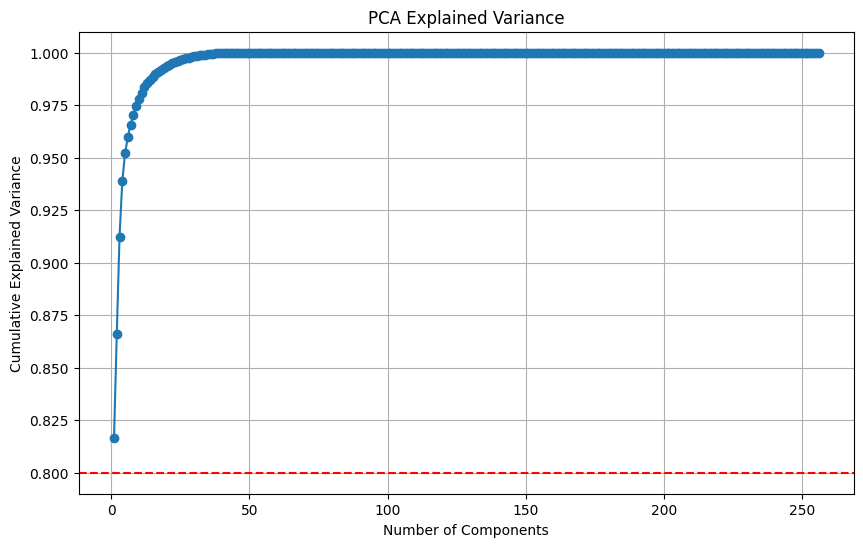

PCA reduced embeddings to 25 dimensions.
(1747, 37)
(390, 37)
   EventType  Hashtags Count  Exclamation_Count  TweetLength  \
0        0.0        1.475610           0.170732    55.878049   
1        0.0        1.338028           0.295775    49.563380   
2        0.0        1.578313           0.253012    51.987952   
3        0.0        1.406250           0.322917    46.572917   
4        0.0        0.811189           0.251748    42.790210   

   TweetCount_PerPeriod  Team_Score  Previous1_TweetFreq  Previous2_TweetFreq  \
0                  82.0        40.0                  0.0                  0.0   
1                  71.0        40.0                 82.0                  0.0   
2                  83.0        40.0                 71.0                 82.0   
3                  96.0        40.0                 83.0                 71.0   
4                 143.0        40.0                 96.0                 83.0   

   Previous3_TweetFreq  Previous4_TweetFreq  ...    PCA_16    PCA_

In [2]:
def load_embeddings(file_path):
    print(f"Loading embeddings from {file_path}...")
    df = pd.read_pickle(file_path)
    df["MatchID"] = df["ID"].apply(lambda x: x.split("_")[0])  # Extract MatchID from ID
    print(f"Loaded {len(df)} PeriodIDs.")
    return df

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import optuna
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.stats import mode

df = pd.read_csv("features.csv")

all_games = df["MatchID"].unique()

# Split games into training and testing sets
np.random.seed(42)
np.random.shuffle(all_games)

all_games = df["MatchID"].unique()
train_df = df[df["MatchID"].isin(all_games[:13])]
test_df = df[df["MatchID"].isin(all_games[13:])]

print(f"Training set has {len(train_df)} entries.")
print(f"Testing set has {len(test_df)} entries.")

train_file = "processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels.pkl"
embeddings_train = load_embeddings(train_file)
embeddings_train["MatchID"] = embeddings_train["MatchID"].astype(int)

emb_train = embeddings_train[embeddings_train["MatchID"].isin(all_games[:13])]
emb_test = embeddings_train[embeddings_train["MatchID"].isin(all_games[13:])]

print(emb_train.shape)
print(emb_test.shape)

# Extract embeddings
train_embeddings = np.vstack(emb_train['aggregated_embedding'].values)  # Shape: (num_train_samples, 256)
test_embeddings = np.vstack(emb_test['aggregated_embedding'].values)    # Shape: (num_test_samples, 256)

# Standardize embeddings
scaler = StandardScaler()
train_embeddings_scaled = scaler.fit_transform(train_embeddings)
test_embeddings_scaled = scaler.transform(test_embeddings)

# Determine number of components to retain 80% variance
pca_full = PCA().fit(train_embeddings_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
print(f"Number of PCA components to retain 80% variance: {n_components_80}")

plt.figure(figsize=(10,6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.80, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

# Apply PCA with 25 components or n_components_80, whichever is larger
desired_components = max(25, n_components_80)
pca = PCA(n_components=desired_components, random_state=42)
train_embeddings_pca = pca.fit_transform(train_embeddings_scaled)
test_embeddings_pca = pca.transform(test_embeddings_scaled)

print(f"PCA reduced embeddings to {desired_components} dimensions.")

# Create DataFrames for PCA components
train_pca_df = pd.DataFrame(train_embeddings_pca, columns=[f'PCA_{i+1}' for i in range(desired_components)])
test_pca_df = pd.DataFrame(test_embeddings_pca, columns=[f'PCA_{i+1}' for i in range(desired_components)])

# Add the ID column to the PCA DataFrames for merging
train_pca_df['ID'] = emb_train['ID'].values
test_pca_df['ID'] = emb_test['ID'].values

# Merge the PCA DataFrames with the original DataFrames using the ID column
train_merged_df = pd.merge(train_df, train_pca_df, on='ID')
test_merged_df = pd.merge(test_df, test_pca_df, on='ID')

# Remove the ID column from the merged DataFrames
train_merged_df.drop(columns=['ID'], inplace=True)
test_merged_df.drop(columns=['ID'], inplace=True)

# Assuming macro features are all columns except 'MatchID', 'PeriodID'
macro_columns = [col for col in train_merged_df.columns if col not in ['MatchID', 'PeriodID']]

train_features = train_merged_df[macro_columns]
test_features = test_merged_df[macro_columns]

print(train_features.shape)
print(test_features.shape)
print(train_features.head())

In [3]:
# Encode target
if 'EventType' not in train_features.columns:
    raise ValueError("EventType not found in the training features.")

y = train_features['EventType'].values
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Drop EventType from training features
train_features = train_features.drop(columns=['EventType'])

print(f"Encoded classes: {le.classes_}")
print(f"Training features shape: {train_features.shape}")

Encoded classes: [0. 1.]
Training features shape: (1747, 36)


In [4]:
# Use all games for cross-validation
unique_games = np.unique(all_games)
np.random.seed(42)
shuffled_games = np.random.permutation(unique_games)

n_splits = 5
folds = np.array_split(shuffled_games, n_splits)

X = train_features
y = y_encoded
game_ids = train_df['MatchID'].values

fold_indices = []
for fold_games in folds:
    val_mask = np.isin(game_ids, fold_games)
    val_idx = np.where(val_mask)[0]
    train_idx = np.where(~val_mask)[0]
    fold_indices.append((train_idx, val_idx))

print("Created game-based fold indices using all games.")

Created game-based fold indices using all games.


In [5]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Define model parameter grids
model_params = {
    'random_forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5, 10]
        }
    },
    'xgboost': {
        'model': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7]
        }
    },
    'catboost': {
        'model': CatBoostClassifier(loss_function="MultiClass", random_seed=42, verbose=0),
        'params': {
            'depth': [4, 6, 8],
            'learning_rate': [0.01, 0.1, 0.2],
            'iterations': [100, 500, 1000]
        }
    }
}

def tune_model_with_gridsearch(model_type, X, y, fold_indices, param_grid):
    """
    Uses GridSearchCV with the provided fold_indices to tune hyperparameters.
    """
    model_info = model_params[model_type]
    base_model = model_info['model']
    grid = model_info['params']

    # Convert custom folds into a generator of (train_idx, val_idx)
    # for GridSearchCV. We'll need to provide pre-defined splits.
    cv_splits = [(train_idx, val_idx) for (train_idx, val_idx) in fold_indices]

    print(f"\nTuning {model_type} with GridSearchCV...")
    grid_search = GridSearchCV(estimator=base_model, param_grid=grid,
                               scoring='accuracy', cv=cv_splits, verbose=1, n_jobs=-1)
    grid_search.fit(X, y)
    print(f"Best parameters for {model_type}: {grid_search.best_params_}")
    return grid_search.best_estimator_, grid_search.best_params_

In [80]:
best_models = {}
best_params = {}

# Tune and select best model for RandomForest
rf_best_model, rf_best_params = tune_model_with_gridsearch('random_forest', X, y, fold_indices, model_params['random_forest']['params'])
best_models['random_forest'] = rf_best_model
best_params['random_forest'] = rf_best_params

# Tune and select best model for XGBoost
xgb_best_model, xgb_best_params = tune_model_with_gridsearch('xgboost', X, y, fold_indices, model_params['xgboost']['params'])
best_models['xgboost'] = xgb_best_model
best_params['xgboost'] = xgb_best_params

# Tune and select best model for CatBoost
cat_best_model, cat_best_params = tune_model_with_gridsearch('catboost', X, y, fold_indices, model_params['catboost']['params'])
best_models['catboost'] = cat_best_model
best_params['catboost'] = cat_best_params

# Evaluate each best model on CV again to compare
def evaluate_cv(model, X, y, fold_indices):
    accuracies = []
    for (train_idx, val_idx) in fold_indices:
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        # Re-initialize the model to ensure no data leakage
        # Since best_models already have chosen parameters, we clone them:
        from sklearn.base import clone
        cloned_model = clone(model)
        cloned_model.fit(X_train_fold, y_train_fold)
        preds = cloned_model.predict(X_val_fold)
        acc = accuracy_score(y_val_fold, preds)
        accuracies.append(acc)
    return np.mean(accuracies)

acc_rf = evaluate_cv(rf_best_model, X, y, fold_indices)
acc_xgb = evaluate_cv(xgb_best_model, X, y, fold_indices)
acc_cat = evaluate_cv(cat_best_model, X, y, fold_indices)

print("\nCross-Validation Accuracy for Best Models:")
print(f"Random Forest: {acc_rf:.4f}")
print(f"XGBoost: {acc_xgb:.4f}")
print(f"CatBoost: {acc_cat:.4f}")

acc_dict = {'random_forest': acc_rf, 'xgboost': acc_xgb, 'catboost': acc_cat}
best_model_name = max(acc_dict, key=acc_dict.get)
print(f"Best model is {best_model_name} with accuracy {acc_dict[best_model_name]:.4f}")


Tuning random_forest with GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for random_forest: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}

Tuning xgboost with GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits


/users/eleves-a/2024/elio.samaha/.local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:53:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/users/eleves-a/2024/elio.samaha/.local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:53:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/users/eleves-a/2024/elio.samaha/.local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:53:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/users/eleves-a/2024/elio.samaha/.local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:53:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/users/eleves-a/2024/elio.samaha/.local/

Best parameters for xgboost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}

Tuning catboost with GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for catboost: {'depth': 8, 'iterations': 1000, 'learning_rate': 0.01}

Cross-Validation Accuracy for Best Models:
Random Forest: 0.7842
XGBoost: 0.7722
CatBoost: 0.7799
Best model is random_forest with accuracy 0.7842


In [82]:
print("Catboost parameters: ", cat_best_params)
print("Random Forest parameters: ", rf_best_params)
print("XGBoost parameters: ", xgb_best_params)

Catboost parameters:  {'depth': 8, 'iterations': 1000, 'learning_rate': 0.01}
Random Forest parameters:  {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
XGBoost parameters:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


In [83]:
print(xgb_best_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)


In [81]:
# Retrain best model on the entire training data
print(f"\nRetraining the best model ({best_model_name}) on the full dataset...")

best_final_model = best_models[best_model_name]
best_final_model.fit(X, y)

# Load final test set for submission
test_file = "processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl"
final_test_df = pd.read_csv("val_features.csv")  # Macro features without embeddings
final_test_embeddings = load_embeddings(test_file)  # Embeddings for the test set

# Extract and scale embeddings for test set
print("Preparing final test embeddings...")
test_embeddings = np.vstack(final_test_embeddings['aggregated_embedding'].values)
test_embeddings_scaled = scaler.transform(test_embeddings)  # scaler fitted on training embeddings

# Apply PCA
test_embeddings_pca = pca.transform(test_embeddings_scaled)  # pca fitted on training embeddings

print(f"Test embeddings PCA shape: {test_embeddings_pca.shape}")

# Create DataFrame for PCA components in test set
pca_columns = [f'PCA_{i+1}' for i in range(pca.n_components_)]
test_pca_df = pd.DataFrame(test_embeddings_pca, columns=pca_columns)
test_pca_df['ID'] = final_test_embeddings['ID'].values

# Merge PCA embeddings with macro features in final_test_df
final_merged_test_df = pd.merge(final_test_df, test_pca_df, on='ID', how='inner')

# Remove ID and any unnecessary columns (e.g., 'MatchID', 'PeriodID', 'EventType' if present)
columns_to_remove = ['ID', 'MatchID', 'PeriodID', 'EventType']
final_merged_test_df.drop(columns=[c for c in columns_to_remove if c in final_merged_test_df.columns], inplace=True, errors='ignore')

print("Final test features shape:", final_merged_test_df.shape)

# Predict on the final test set
print("Predicting on final test set...")
final_preds = best_final_model.predict(final_merged_test_df)
final_preds_labels = le.inverse_transform(final_preds)

submission = pd.DataFrame({
    "ID": final_test_df["ID"],
    "EventType": final_preds_labels
})
submission.to_csv("Tree_RF_submission.csv", index=False)
print("Final submission 'submission.csv' created successfully.")


Retraining the best model (random_forest) on the full dataset...
Loading embeddings from processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl...
Loaded 516 PeriodIDs.
Preparing final test embeddings...
Test embeddings PCA shape: (516, 25)
Final test features shape: (516, 36)
Predicting on final test set...
Final submission 'submission.csv' created successfully.


In [ ]:
next_final_model = best_models["catboost"]
next_final_model.fit(X, y)


# Predict on the final test set
print("Predicting on final test set...")
final_preds = next_final_model.predict(final_merged_test_df)
final_preds_labels = le.inverse_transform(final_preds)

submission = pd.DataFrame({
    "ID": final_test_df["ID"],
    "EventType": final_preds_labels
})
submission.to_csv("CatBoost_submission.csv", index=False)
print("Final submission 'submission.csv' created successfully.")

Predicting on final test set...
Final submission 'submission.csv' created successfully.


# submission

In [6]:
# doing a check
submission_model = RandomForestClassifier(random_state=42, max_depth = None, min_samples_split = 10, n_estimators = 200)
submission_model.fit(X, y)

# Load final test set for submission
test_file = "processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl"
final_test_df = pd.read_csv("val_features.csv")  # Macro features without embeddings
final_test_embeddings = load_embeddings(test_file)  # Embeddings for the test set

# Extract and scale embeddings for test set
print("Preparing final test embeddings...")
test_embeddings = np.vstack(final_test_embeddings['aggregated_embedding'].values)
test_embeddings_scaled = scaler.transform(test_embeddings)  # scaler fitted on training embeddings

# Apply PCA
test_embeddings_pca = pca.transform(test_embeddings_scaled)  # pca fitted on training embeddings

print(f"Test embeddings PCA shape: {test_embeddings_pca.shape}")

# Create DataFrame for PCA components in test set
pca_columns = [f'PCA_{i+1}' for i in range(pca.n_components_)]
test_pca_df = pd.DataFrame(test_embeddings_pca, columns=pca_columns)
test_pca_df['ID'] = final_test_embeddings['ID'].values

# Merge PCA embeddings with macro features in final_test_df
final_merged_test_df = pd.merge(final_test_df, test_pca_df, on='ID', how='inner')

# Remove ID and any unnecessary columns (e.g., 'MatchID', 'PeriodID', 'EventType' if present)
columns_to_remove = ['ID', 'MatchID', 'PeriodID', 'EventType']
final_merged_test_df.drop(columns=[c for c in columns_to_remove if c in final_merged_test_df.columns], inplace=True, errors='ignore')

print("Final test features shape:", final_merged_test_df.shape)

# Predict on the final test set
print("Predicting on final test set...")
final_preds = submission_model.predict(final_merged_test_df)
final_preds_labels = le.inverse_transform(final_preds)

submission = pd.DataFrame({
    "ID": final_test_df["ID"],
    "EventType": final_preds_labels
})
submission.to_csv("Tree_RF_submission_check.csv", index=False)
print("Final submission 'submission.csv' created successfully.")

Loading embeddings from processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl...
Loaded 516 PeriodIDs.
Preparing final test embeddings...
Test embeddings PCA shape: (516, 25)
Final test features shape: (516, 36)
Predicting on final test set...
Final submission 'submission.csv' created successfully.
